# Evaluación del modelo de clustering — FPA Latam
## Notebook `05_evaluation/01_evaluacion_clustering.ipynb`

Este notebook valida el modelo de clustering construido en `04_modeling/01_clustering.ipynb`.  
**No re-entrena modelos**; opera exclusivamente sobre los artefactos exportados en `04_modeling/outputs/`.

| Parámetro | Valor |
|---|---|
| Capa 1 — fuente | SRI (variables firmográficas) |
| Capa 1 — empresas | Se recalcula desde `clusters_capa1.csv` |
| Capa 1 — K elegido | K = 4 |
| Capa 2 — fuente | SRI + ranking SCVS |
| Capa 2 — empresas | Se recalcula desde `clusters_capa2.csv` |
| Capa 2 — K elegido | K = 2 |
| Clientes FPA Capa 1 | Tasa recalculada dinamicamente |
| Clientes FPA Capa 2 | Tasa recalculada dinamicamente |

`es_cliente_fpa` se usa solo para validacion externa agregada por cluster. No forma parte de las matrices de K-Means y no se reportan resultados empresa por empresa.

## 1. Importación de librerías y configuración de rutas

In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from scipy.stats import chi2_contingency, spearmanr

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.cluster import KMeans
from sklearn.metrics import (
    silhouette_score, silhouette_samples,
    davies_bouldin_score, adjusted_rand_score
)

# ── Rutas ──────────────────────────────────────────────────────────────────────
ROOT        = Path(r"E:\TESIS MAESTRIA\Desarrollo_clustering_maestria")
FE_OUT      = ROOT / "03_feature_engineering" / "outputs"
MOD_OUT     = ROOT / "04_modeling" / "outputs"
EVAL_OUT    = ROOT / "05_evaluation" / "outputs"
EVAL_OUT.mkdir(parents=True, exist_ok=True)

# ── Estética ───────────────────────────────────────────────────────────────────
PALETTE_C1 = ["#2196F3", "#4CAF50", "#FF9800", "#9C27B0"]   # 4 clusters Capa 1
PALETTE_C2 = ["#2196F3", "#FF5722"]                          # 2 clusters Capa 2
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

print("✓ Librerías cargadas")
print(f"  Outputs modelado : {MOD_OUT}")
print(f"  Outputs evaluación: {EVAL_OUT}")

✓ Librerías cargadas
  Outputs modelado : E:\TESIS MAESTRIA\Desarrollo_clustering_maestria\04_modeling\outputs
  Outputs evaluación: E:\TESIS MAESTRIA\Desarrollo_clustering_maestria\05_evaluation\outputs


## 2. Carga de artefactos del modelo

In [2]:
# ── Matrices de features (para PCA / silhouette recalculado) ──────────────────
# FE exports: matriz_capa1/2.csv contienen SOLO features (sin RUC)
#             labels_capa1/2.csv contienen los metadatos (RUC, es_cliente_fpa, etc.)
matriz_c1_raw   = pd.read_csv(FE_OUT / "matriz_capa1.csv")
labels_c1_raw   = pd.read_csv(FE_OUT / "labels_capa1.csv")

matriz_c2_raw   = pd.read_csv(FE_OUT / "matriz_capa2.csv")
labels_c2_meta  = pd.read_csv(FE_OUT / "labels_capa2.csv")
features_c2_raw = pd.read_csv(FE_OUT / "features_capa2.csv")

# Etiquetas de cluster y metadatos del modelo
clusters_c1    = pd.read_csv(MOD_OUT / "clusters_capa1.csv")
clusters_c2    = pd.read_csv(MOD_OUT / "clusters_capa2.csv")
clusters_c2_k4 = pd.read_csv(MOD_OUT / "clusters_capa2_k4_sensibilidad.csv")

# Perfiles y métricas
perfil_c1      = pd.read_csv(MOD_OUT / "perfil_clusters_capa1.csv")
perfil_c2      = pd.read_csv(MOD_OUT / "perfil_clusters_capa2.csv")
perfil_c2_k4   = pd.read_csv(MOD_OUT / "perfil_clusters_capa2_k4.csv")
met_kmeans_c1  = pd.read_csv(MOD_OUT / "metricas_kmeans_capa1.csv")
met_kmeans_c2  = pd.read_csv(MOD_OUT / "metricas_kmeans_capa2.csv")
met_ward_c1    = pd.read_csv(MOD_OUT / "metricas_ward_capa1.csv")
met_ward_c2    = pd.read_csv(MOD_OUT / "metricas_ward_capa2.csv")
cobertura_c1   = pd.read_csv(MOD_OUT / "cobertura_financiera_por_cluster_capa1.csv")
comparacion    = pd.read_csv(MOD_OUT / "comparacion_capas_best_k.csv")
comp_same_k    = pd.read_csv(MOD_OUT / "comparacion_capas_same_k.csv")

# ── Construir matriz escalada de Capa 1 ───────────────────────────────────────
# Combinar matriz (features) con labels (metadatos) — están alineados por índice
df_c1_full = pd.concat([labels_c1_raw, matriz_c1_raw], axis=1)
cols_modelo_c1 = matriz_c1_raw.columns.tolist()

# Deduplicar: conservar max(es_cliente_fpa) por RUC
df_c1_dedup = (
    df_c1_full
    .sort_values("es_cliente_fpa", ascending=False)
    .drop_duplicates(subset="RUC", keep="first")
    .reset_index(drop=True)
)
print(f"Matriz Capa 1: {len(df_c1_dedup)} filas tras deduplicar (original: {len(df_c1_full)})")

# Escalar
scaler_c1   = StandardScaler()
X_c1_scaled = scaler_c1.fit_transform(df_c1_dedup[cols_modelo_c1])

# Etiquetas de cluster — alinear por RUC
labels_c1   = clusters_c1.set_index("RUC").reindex(df_c1_dedup["RUC"])["cluster_capa1"].values
print(f"Labels Capa 1: {np.unique(labels_c1, return_counts=True)}")

# ── Matriz escalada Capa 2 ─────────────────────────────────────────────────────
# Usar features_capa2.csv que contiene el RUC para alineación
rucs_c2     = labels_c2_meta["RUC"].values          # RUCs alineados con matriz_c2_raw
cols_modelo_c2 = matriz_c2_raw.columns.tolist()

scaler_c2   = StandardScaler()
X_c2_scaled = scaler_c2.fit_transform(matriz_c2_raw)
labels_c2   = clusters_c2.set_index("RUC").reindex(rucs_c2)["cluster_capa2"].values
print(f"Matriz Capa 2: {len(matriz_c2_raw)} filas")
print(f"Labels Capa 2: {np.unique(labels_c2, return_counts=True)}")

# ── Verificaciones de integridad ───────────────────────────────────────────────
n_c1_dedup    = len(df_c1_dedup)
n_c2_features = len(features_c2_raw)

assert df_c1_dedup["RUC"].nunique() == n_c1_dedup, "Duplicados en Capa 1"
assert n_c2_features == len(matriz_c2_raw), f"Desajuste filas Capa 2: features={n_c2_features}, matriz={len(matriz_c2_raw)}"

fpa_c1 = clusters_c1["es_cliente_fpa"].sum()
fpa_c2 = clusters_c2["es_cliente_fpa"].sum()
print(f"\n✓ Integridad OK")
print(f"  Capa 1: {n_c1_dedup} filas deduplicadas")
print(f"  Capa 2: {n_c2_features} filas")
print(f"  Clientes FPA Capa 1: {fpa_c1} / {len(clusters_c1)}  = {fpa_c1/len(clusters_c1):.1%}")
print(f"  Clientes FPA Capa 2: {fpa_c2} / {len(clusters_c2)}  = {fpa_c2/len(clusters_c2):.1%}")


Matriz Capa 1: 181 filas tras deduplicar (original: 181)
Labels Capa 1: (array([0, 1, 2, 3]), array([46, 35, 60, 40]))
Matriz Capa 2: 141 filas
Labels Capa 2: (array([0, 1]), array([110,  31]))

✓ Integridad OK
  Capa 1: 181 filas deduplicadas
  Capa 2: 141 filas
  Clientes FPA Capa 1: 82 / 181  = 45.3%
  Clientes FPA Capa 2: 57 / 141  = 40.4%


## 3. Validación interna: Silhouette, Davies-Bouldin e Inercia

In [3]:
# ── Métricas internas recalculadas sobre las asignaciones finales ─────────────
sil_c1  = silhouette_score(X_c1_scaled, labels_c1)
db_c1   = davies_bouldin_score(X_c1_scaled, labels_c1)
sil_c2  = silhouette_score(X_c2_scaled, labels_c2)
db_c2   = davies_bouldin_score(X_c2_scaled, labels_c2)

print("=== Métricas internas (modelo final) ===")
print(f"Capa 1  K=4  Silhouette={sil_c1:.3f}  Davies-Bouldin={db_c1:.3f}")
print(f"Capa 2  K=2  Silhouette={sil_c2:.3f}  Davies-Bouldin={db_c2:.3f}")

# ── Tabla comparativa K vs métricas (KMeans + Ward) ──────────────────────────
print("\n=== Métricas KMeans Capa 1 (por K) ===")
display(met_kmeans_c1.set_index("k").round(3))

print("=== Métricas Ward Capa 1 (por K) ===")
display(met_ward_c1.set_index("k").round(3))

print("=== Métricas KMeans Capa 2 (por K) ===")
display(met_kmeans_c2.set_index("k").round(3))

=== Métricas internas (modelo final) ===
Capa 1  K=4  Silhouette=0.130  Davies-Bouldin=2.088
Capa 2  K=2  Silhouette=0.284  Davies-Bouldin=1.664

=== Métricas KMeans Capa 1 (por K) ===


,inertia,silhouette,davies_bouldin,min_cluster_size,max_cluster_size
k,,,,,
2,380.683,0.224,1.590,66,115
3,329.789,0.192,1.838,56,64
4,295.682,0.209,1.601,35,60
5,267.000,0.215,1.453,27,44
6,250.692,0.208,1.529,17,43
7,233.972,0.213,1.469,11,39
8,221.393,0.192,1.591,10,29


=== Métricas Ward Capa 1 (por K) ===


,silhouette,davies_bouldin,min_cluster_size,max_cluster_size
k,,,,
2,0.176,1.871,74,107
3,0.139,2.111,50,74
4,0.138,1.908,30,57
5,0.166,1.698,23,50
6,0.180,1.684,21,50


=== Métricas KMeans Capa 2 (por K) ===


,inertia,silhouette,davies_bouldin,min_cluster_size,max_cluster_size
k,,,,,
2,837.879,0.379,1.212,31,110
3,720.268,0.197,1.605,17,71
4,620.537,0.209,1.341,3,71
5,549.378,0.233,1.141,2,84
6,500.288,0.172,1.299,2,70
7,452.113,0.182,1.241,2,53
8,414.206,0.178,1.240,2,42


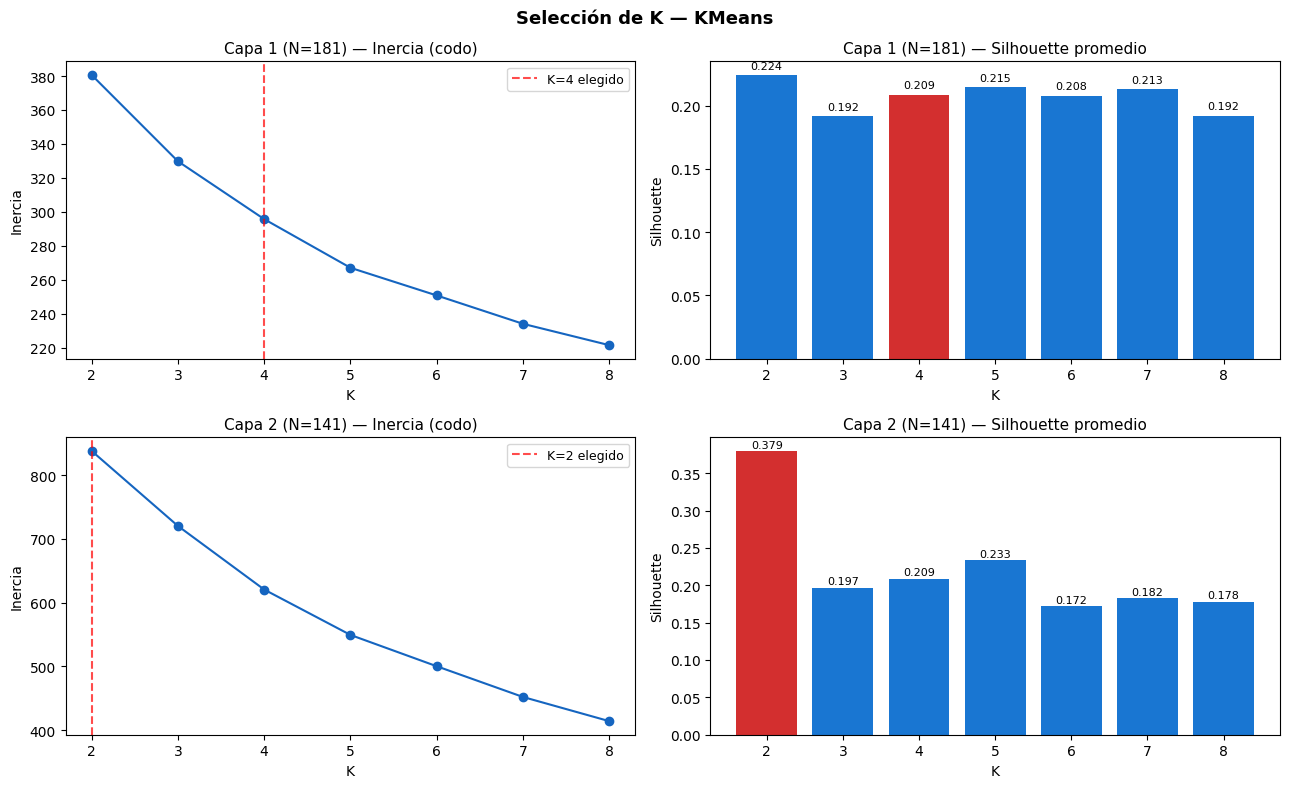

✓ Guardado: fig_seleccion_k_kmeans.png


In [4]:
# ── Curvas de elbow + Silhouette (KMeans, Capa 1 y Capa 2) ───────────────────
fig, axes = plt.subplots(2, 2, figsize=(13, 8))
fig.suptitle("Selección de K — KMeans", fontsize=13, fontweight="bold")

for ax_row, (met, capa, chosen) in enumerate([
    (met_kmeans_c1, f"Capa 1 (N={len(clusters_c1)})", 4),
    (met_kmeans_c2, f"Capa 2 (N={len(clusters_c2)})",  2),
]):
    ax_iner = axes[ax_row, 0]
    ax_sil  = axes[ax_row, 1]

    ax_iner.plot(met["k"], met["inertia"], "o-", color="#1565C0")
    ax_iner.axvline(chosen, color="red", linestyle="--", alpha=0.7, label=f"K={chosen} elegido")
    ax_iner.set_title(f"{capa} — Inercia (codo)", fontsize=11)
    ax_iner.set_xlabel("K"); ax_iner.set_ylabel("Inercia")
    ax_iner.legend(fontsize=9)

    color_sil = ["#D32F2F" if k == chosen else "#1976D2" for k in met["k"]]
    ax_sil.bar(met["k"], met["silhouette"], color=color_sil)
    ax_sil.set_title(f"{capa} — Silhouette promedio", fontsize=11)
    ax_sil.set_xlabel("K"); ax_sil.set_ylabel("Silhouette")
    for k, v in zip(met["k"], met["silhouette"]):
        ax_sil.text(k, v + 0.005, f"{v:.3f}", ha="center", fontsize=8)

plt.tight_layout()
fig.savefig(EVAL_OUT / "fig_seleccion_k_kmeans.png", dpi=150, bbox_inches="tight")
plt.show()
print("✓ Guardado: fig_seleccion_k_kmeans.png")

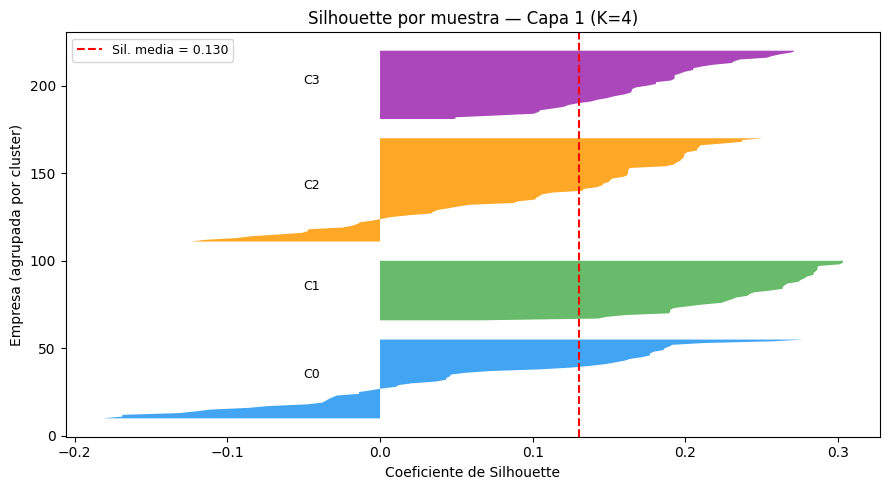

✓ Guardado: fig_silhouette_muestras_c1.png


In [5]:
# ── Gráfico de Silhouette por muestra — Capa 1 K=4 ───────────────────────────
sil_samples_c1 = silhouette_samples(X_c1_scaled, labels_c1)

fig, ax = plt.subplots(figsize=(9, 5))
y_lower = 10
for i in range(4):
    ith_sil = np.sort(sil_samples_c1[labels_c1 == i])
    size_i  = ith_sil.shape[0]
    y_upper = y_lower + size_i
    ax.fill_betweenx(np.arange(y_lower, y_upper), 0, ith_sil,
                     facecolor=PALETTE_C1[i], edgecolor="none", alpha=0.85)
    ax.text(-0.05, y_lower + 0.5 * size_i, f"C{i}", fontsize=9)
    y_lower = y_upper + 10

ax.axvline(sil_c1, color="red", linestyle="--", label=f"Sil. media = {sil_c1:.3f}")
ax.set_xlabel("Coeficiente de Silhouette"); ax.set_ylabel("Empresa (agrupada por cluster)")
ax.set_title("Silhouette por muestra — Capa 1 (K=4)", fontsize=12)
ax.legend(fontsize=9)
plt.tight_layout()
fig.savefig(EVAL_OUT / "fig_silhouette_muestras_c1.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"✓ Guardado: fig_silhouette_muestras_c1.png")

## 4. Validación externa: tasa de clientes FPA por cluster

In [6]:
# ── Tabla de validación externa FPA — Capa 1 ─────────────────────────────────
TASA_BASE_C1 = clusters_c1["es_cliente_fpa"].mean()

val_c1 = (
    clusters_c1
    .groupby("cluster_capa1")
    .agg(
        segmento=("segmento_capa1", "first"),
        n=("es_cliente_fpa", "count"),
        clientes_fpa=("es_cliente_fpa", "sum"),
    )
    .assign(tasa_clientes=lambda d: d["clientes_fpa"] / d["n"])
    .reset_index()
)
val_c1["vs_base"] = val_c1["tasa_clientes"] - TASA_BASE_C1
print("=== Validación externa — Capa 1 ===")
display(val_c1.round(4))

# ── Chi-cuadrado ──────────────────────────────────────────────────────────────
contingencia_c1 = pd.crosstab(clusters_c1["cluster_capa1"], clusters_c1["es_cliente_fpa"])
chi2_c1, p_c1, dof_c1, _ = chi2_contingency(contingencia_c1)
print(f"\nChi-cuadrado Capa 1: χ²={chi2_c1:.3f}  p={p_c1:.4f}  gl={dof_c1}")
if p_c1 < 0.05:
    print("→ La distribución de clientes FPA difiere significativamente entre clusters (p < 0.05)")
else:
    print("→ No se detecta diferencia significativa (p ≥ 0.05)")

# ── Tabla validación Capa 2 ───────────────────────────────────────────────────
TASA_BASE_C2 = clusters_c2["es_cliente_fpa"].mean()
val_c2 = (
    clusters_c2
    .groupby("cluster_capa2")
    .agg(
        segmento=("segmento_capa2", "first"),
        n=("es_cliente_fpa", "count"),
        clientes_fpa=("es_cliente_fpa", "sum"),
    )
    .assign(tasa_clientes=lambda d: d["clientes_fpa"] / d["n"])
    .reset_index()
)
val_c2["vs_base"] = val_c2["tasa_clientes"] - TASA_BASE_C2
print("\n=== Validación externa — Capa 2 ===")
display(val_c2.round(4))

contingencia_c2 = pd.crosstab(clusters_c2["cluster_capa2"], clusters_c2["es_cliente_fpa"])
chi2_c2, p_c2, dof_c2, _ = chi2_contingency(contingencia_c2)
print(f"\nChi-cuadrado Capa 2: χ²={chi2_c2:.3f}  p={p_c2:.4f}  gl={dof_c2}")

=== Validación externa — Capa 1 ===


,cluster_capa1,segmento,n,clientes_fpa,tasa_clientes,vs_base
0,0,Comercio formal maduro en Pichincha,46,20,0.4348,-0.0183
1,1,Industriales consolidados de alta afinidad FPA,35,23,0.6571,0.2041
2,2,Comercio formal emergente en Pichincha,60,23,0.3833,-0.0697
3,3,Comercio formal regional en Guayas,40,16,0.4000,-0.0530



Chi-cuadrado Capa 1: χ²=7.577  p=0.0556  gl=3
→ No se detecta diferencia significativa (p ≥ 0.05)

=== Validación externa — Capa 2 ===


,cluster_capa2,segmento,n,clientes_fpa,tasa_clientes,vs_base
0,0,Empresas grandes consolidadas,110,43,0.3909,-0.0133
1,1,Empresas medianas y recientes de alta afinidad,31,14,0.4516,0.0474



Chi-cuadrado Capa 2: χ²=0.161  p=0.6883  gl=1


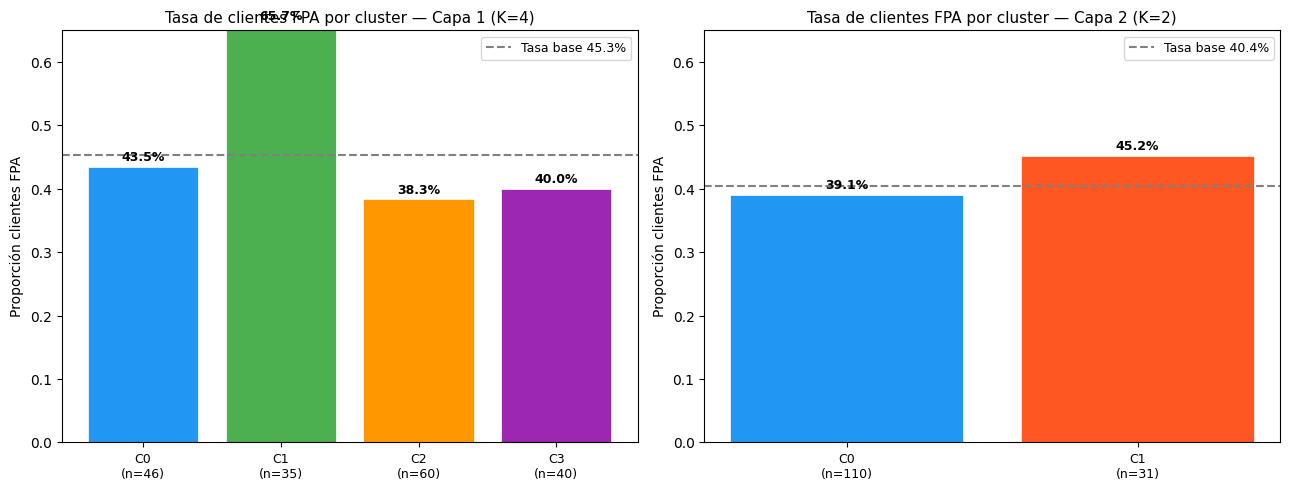

✓ Guardado: fig_tasa_fpa_por_cluster.png


In [7]:
# ── Gráfico: Tasa FPA por cluster — Capa 1 y Capa 2 ─────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for ax, val_df, palette, base, capa, k in [
    (axes[0], val_c1, PALETTE_C1, TASA_BASE_C1, "Capa 1 (K=4)", 4),
    (axes[1], val_c2, PALETTE_C2, TASA_BASE_C2, "Capa 2 (K=2)", 2),
]:
    bars = ax.bar(val_df.index, val_df["tasa_clientes"],
                  color=palette[:k], edgecolor="white", linewidth=0.5)
    ax.axhline(base, color="gray", linestyle="--", linewidth=1.5, label=f"Tasa base {base:.1%}")
    ax.set_xticks(val_df.index)
    ax.set_xticklabels([f"C{c}\n(n={n})" for c, n in zip(val_df.iloc[:, 0], val_df["n"])],
                       fontsize=9)
    ax.set_ylabel("Proporción clientes FPA")
    ax.set_title(f"Tasa de clientes FPA por cluster — {capa}", fontsize=11)
    ax.set_ylim(0, 0.65)
    for bar, tasa in zip(bars, val_df["tasa_clientes"]):
        ax.text(bar.get_x() + bar.get_width() / 2, tasa + 0.01,
                f"{tasa:.1%}", ha="center", fontsize=9, fontweight="bold")
    ax.legend(fontsize=9)

plt.tight_layout()
fig.savefig(EVAL_OUT / "fig_tasa_fpa_por_cluster.png", dpi=150, bbox_inches="tight")
plt.show()
print("✓ Guardado: fig_tasa_fpa_por_cluster.png")

## 5. Análisis de concordancia entre capas (ARI)

In [8]:
# ── ARI entre capas ───────────────────────────────────────────────────────────
# Empresas comunes (presentes en ambas capas)
comun = comparacion[["RUC", "cluster_capa1", "cluster_capa2"]].dropna()
comun_k4 = comp_same_k[["RUC", "cluster_capa1", "cluster_capa2_k4"]].dropna()

ari_best = adjusted_rand_score(comun["cluster_capa1"], comun["cluster_capa2"])
ari_same = adjusted_rand_score(comun_k4["cluster_capa1"], comun_k4["cluster_capa2_k4"])

print(f"ARI  Capa1 K=4 vs Capa2 K=2  (mejor K por capa) : {ari_best:.3f}")
print(f"ARI  Capa1 K=4 vs Capa2 K=4  (misma granularidad): {ari_same:.3f}")
print(f"\nEmpresas comunes analizadas: {len(comun)}")

# ── Tabla de correspondencia ──────────────────────────────────────────────────
print("\n=== Tabla de correspondencia: Capa1 K=4 × Capa2 K=2 ===")
ct_best = pd.crosstab(comun["cluster_capa1"], comun["cluster_capa2"],
                      rownames=["Cluster Capa1"], colnames=["Cluster Capa2"])
display(ct_best)

print("=== Tabla de correspondencia: Capa1 K=4 × Capa2 K=4 ===")
ct_same = pd.crosstab(comun_k4["cluster_capa1"], comun_k4["cluster_capa2_k4"],
                      rownames=["Cluster Capa1"], colnames=["Cluster Capa2 K4"])
display(ct_same)

ARI  Capa1 K=4 vs Capa2 K=2  (mejor K por capa) : 0.032
ARI  Capa1 K=4 vs Capa2 K=4  (misma granularidad): 0.126

Empresas comunes analizadas: 141

=== Tabla de correspondencia: Capa1 K=4 × Capa2 K=2 ===


Cluster Capa2,0,1
Cluster Capa1,,
0,37,2
1,22,0
2,24,21
3,27,8


=== Tabla de correspondencia: Capa1 K=4 × Capa2 K=4 ===


Cluster Capa2 K4,0,1,2,3
Cluster Capa1,,,,
0,31,1,6,1
1,19,0,3,0
2,6,12,25,2
3,15,2,18,0


## 6. Visualización en espacio reducido: PCA y t-SNE

Capa 1 — Varianza explicada PC1+PC2: 35.4%  (PC1=21.1%, PC2=14.2%)


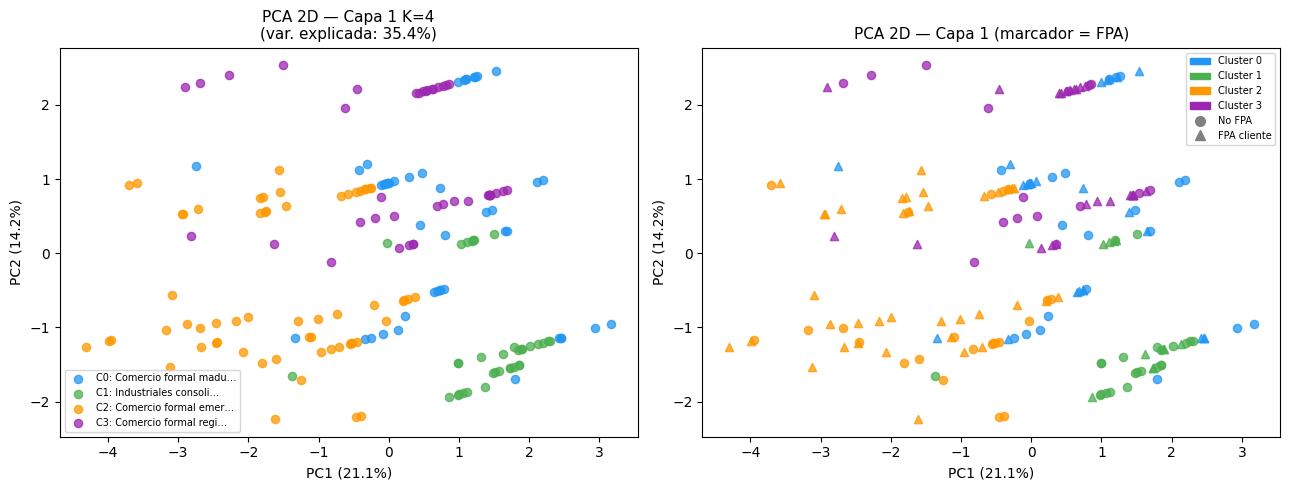

✓ Guardado: fig_pca_capa1.png


In [9]:
# ── PCA 2D — Capa 1 ──────────────────────────────────────────────────────────
pca_c1 = PCA(n_components=2, random_state=RANDOM_STATE)
Z_pca_c1 = pca_c1.fit_transform(X_c1_scaled)
var_exp_c1 = pca_c1.explained_variance_ratio_
print(f"Capa 1 — Varianza explicada PC1+PC2: {var_exp_c1.sum():.1%}  (PC1={var_exp_c1[0]:.1%}, PC2={var_exp_c1[1]:.1%})")

fpa_c1_arr = clusters_c1.set_index("RUC").reindex(df_c1_dedup["RUC"])["es_cliente_fpa"].values

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for ax, title_suffix in [(axes[0], "color=cluster"), (axes[1], "forma=FPA")]:
    for cl in range(4):
        mask = labels_c1 == cl
        nm   = perfil_c1.loc[perfil_c1["cluster_capa1"] == cl, "segmento_capa1"].values[0]
        if title_suffix == "color=cluster":
            ax.scatter(Z_pca_c1[mask, 0], Z_pca_c1[mask, 1],
                       c=PALETTE_C1[cl], s=35, alpha=0.75, label=f"C{cl}: {nm[:20]}…")
        else:
            markers = ["o" if fpa else "^" for fpa in fpa_c1_arr[mask]]
            for x, y, m in zip(Z_pca_c1[mask, 0], Z_pca_c1[mask, 1], markers):
                ax.scatter(x, y, c=PALETTE_C1[cl], s=35, alpha=0.75, marker=m)

ax0 = axes[0]
ax0.set_title(f"PCA 2D — Capa 1 K=4\n(var. explicada: {var_exp_c1.sum():.1%})", fontsize=11)
ax0.set_xlabel(f"PC1 ({var_exp_c1[0]:.1%})")
ax0.set_ylabel(f"PC2 ({var_exp_c1[1]:.1%})")
ax0.legend(fontsize=7, loc="best")

ax1 = axes[1]
ax1.set_title("PCA 2D — Capa 1 (marcador = FPA)", fontsize=11)
ax1.set_xlabel(f"PC1 ({var_exp_c1[0]:.1%})")
ax1.set_ylabel(f"PC2 ({var_exp_c1[1]:.1%})")
legend_patches = [
    mpatches.Patch(color=PALETTE_C1[i], label=f"Cluster {i}") for i in range(4)
] + [
    plt.Line2D([0], [0], marker="o", color="gray", label="No FPA", linestyle="None", markersize=7),
    plt.Line2D([0], [0], marker="^", color="gray", label="FPA cliente", linestyle="None", markersize=7),
]
ax1.legend(handles=legend_patches, fontsize=7, loc="best")

plt.tight_layout()
fig.savefig(EVAL_OUT / "fig_pca_capa1.png", dpi=150, bbox_inches="tight")
plt.show()
print("✓ Guardado: fig_pca_capa1.png")

  File "C:\Users\asus\AppData\Roaming\Python\Python312\site-packages\joblib\externals\loky\backend\context.py", line 255, in _count_physical_cores
    raise ValueError(f"found {cpu_count_physical} physical cores < 1")


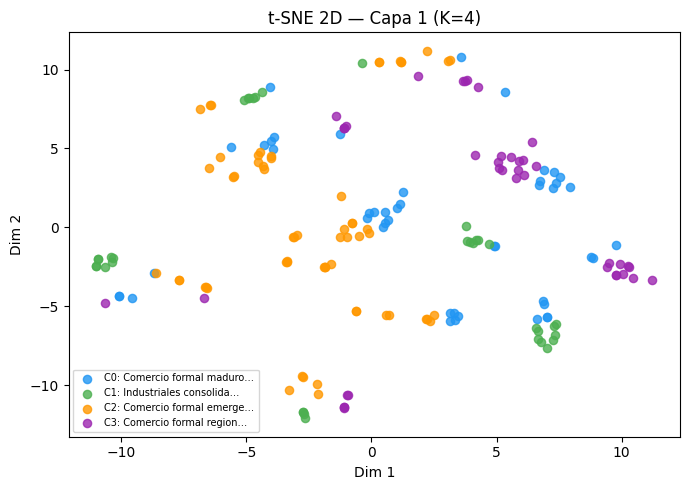

✓ Guardado: fig_tsne_capa1.png

Capa 2 — Varianza explicada PC1+PC2: 38.4%


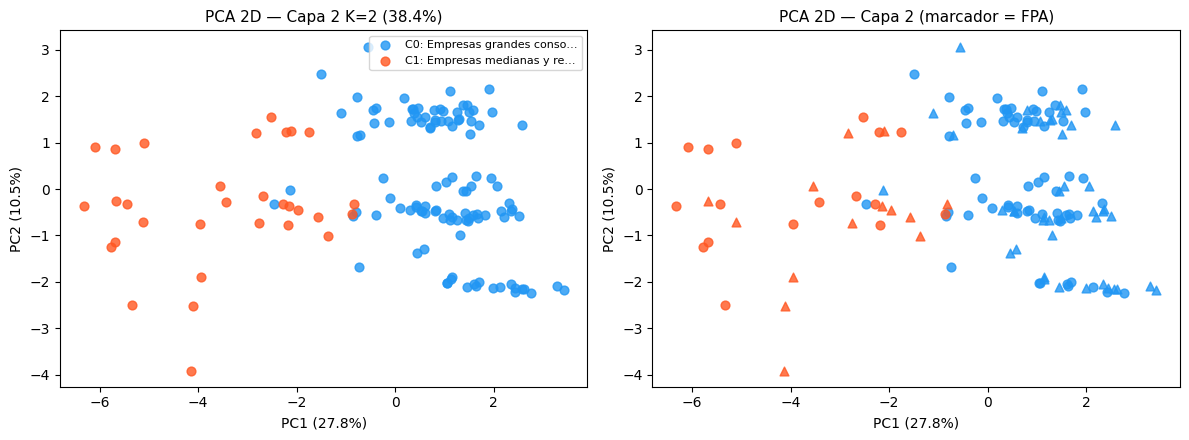

✓ Guardado: fig_pca_capa2.png


In [10]:
# ── t-SNE 2D — Capa 1 ────────────────────────────────────────────────────────
tsne_c1 = TSNE(n_components=2, perplexity=30, random_state=RANDOM_STATE, max_iter=1000)
Z_tsne_c1 = tsne_c1.fit_transform(X_c1_scaled)

fig, ax = plt.subplots(figsize=(7, 5))
for cl in range(4):
    mask = labels_c1 == cl
    nm   = perfil_c1.loc[perfil_c1["cluster_capa1"] == cl, "segmento_capa1"].values[0]
    ax.scatter(Z_tsne_c1[mask, 0], Z_tsne_c1[mask, 1],
               c=PALETTE_C1[cl], s=35, alpha=0.8, label=f"C{cl}: {nm[:22]}…")
ax.set_title("t-SNE 2D — Capa 1 (K=4)", fontsize=12)
ax.set_xlabel("Dim 1"); ax.set_ylabel("Dim 2")
ax.legend(fontsize=7, loc="best")
plt.tight_layout()
fig.savefig(EVAL_OUT / "fig_tsne_capa1.png", dpi=150, bbox_inches="tight")
plt.show()
print("✓ Guardado: fig_tsne_capa1.png")

# ── PCA 2D — Capa 2 ──────────────────────────────────────────────────────────
pca_c2 = PCA(n_components=2, random_state=RANDOM_STATE)
Z_pca_c2 = pca_c2.fit_transform(X_c2_scaled)
var_exp_c2 = pca_c2.explained_variance_ratio_
fpa_c2_arr = clusters_c2.set_index("RUC").reindex(labels_c2_meta["RUC"])["es_cliente_fpa"].values
print(f"\nCapa 2 — Varianza explicada PC1+PC2: {var_exp_c2.sum():.1%}")

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
for ax, title_suffix in [(axes[0], "cluster"), (axes[1], "FPA")]:
    for cl in range(2):
        mask = labels_c2 == cl
        nm   = perfil_c2.loc[perfil_c2["cluster_capa2"] == cl, "segmento_capa2"].values[0]
        if title_suffix == "cluster":
            ax.scatter(Z_pca_c2[mask, 0], Z_pca_c2[mask, 1],
                       c=PALETTE_C2[cl], s=40, alpha=0.8, label=f"C{cl}: {nm[:22]}…")
        else:
            for x, y, fpa in zip(Z_pca_c2[mask, 0], Z_pca_c2[mask, 1], fpa_c2_arr[mask]):
                ax.scatter(x, y, c=PALETTE_C2[cl], s=40, alpha=0.8,
                           marker="^" if fpa else "o")

axes[0].set_title(f"PCA 2D — Capa 2 K=2 ({var_exp_c2.sum():.1%})", fontsize=11)
axes[1].set_title("PCA 2D — Capa 2 (marcador = FPA)", fontsize=11)
for ax in axes:
    ax.set_xlabel(f"PC1 ({var_exp_c2[0]:.1%})"); ax.set_ylabel(f"PC2 ({var_exp_c2[1]:.1%})")
axes[0].legend(fontsize=8, loc="best")

plt.tight_layout()
fig.savefig(EVAL_OUT / "fig_pca_capa2.png", dpi=150, bbox_inches="tight")
plt.show()
print("✓ Guardado: fig_pca_capa2.png")

## 7. Análisis de sesgo de cobertura financiera (SCVS)

=== Cobertura financiera por cluster de Capa 1 ===


,cluster_capa1,segmento_capa1,n_total,n_con_financieras,cobertura_financiera,tasa_clientes_fpa
0,0,Comercio formal maduro en Pichincha,46,39,0.8478,0.4348
1,1,Industriales consolidados de alta afinidad FPA,35,22,0.6286,0.6571
2,2,Comercio formal emergente en Pichincha,60,45,0.7500,0.3833
3,3,Comercio formal regional en Guayas,40,35,0.8750,0.4000



✓ Ningún cluster tiene cobertura SCVS = 0%; cobertura mínima observada: 62.9%

Correlación Spearman (cobertura_SCVS ~ tasa_FPA): ρ=-0.400  p=0.6000


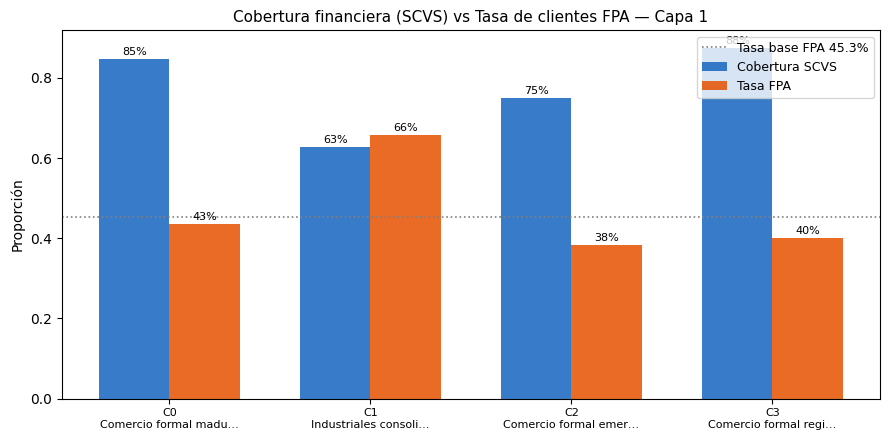

✓ Guardado: fig_cobertura_vs_fpa.png


In [11]:
# ── Cobertura SCVS por cluster de Capa 1 ─────────────────────────────────────
print("=== Cobertura financiera por cluster de Capa 1 ===")
display(cobertura_c1.round(4))

# Verificación dinámica de cobertura financiera.
clusters_cob0 = cobertura_c1.loc[cobertura_c1["cobertura_financiera"] == 0.0, "cluster_capa1"].tolist()
if clusters_cob0:
    print(f"\n✓ Cluster(s) con cobertura SCVS = 0%: {clusters_cob0} — CONFIRMADO")
else:
    min_cov = cobertura_c1["cobertura_financiera"].min()
    print(f"\n✓ Ningún cluster tiene cobertura SCVS = 0%; cobertura mínima observada: {min_cov:.1%}")

# ── Correlación Spearman: cobertura vs tasa FPA ───────────────────────────────
rho, p_rho = spearmanr(cobertura_c1["cobertura_financiera"], cobertura_c1["tasa_clientes_fpa"])
print(f"\nCorrelación Spearman (cobertura_SCVS ~ tasa_FPA): ρ={rho:.3f}  p={p_rho:.4f}")

# ── Gráfico: cobertura y tasa FPA por cluster ─────────────────────────────────
fig, ax = plt.subplots(figsize=(9, 4.5))
x = np.arange(len(cobertura_c1))
width = 0.35
bars1 = ax.bar(x - width/2, cobertura_c1["cobertura_financiera"], width,
               label="Cobertura SCVS", color="#1565C0", alpha=0.85)
bars2 = ax.bar(x + width/2, cobertura_c1["tasa_clientes_fpa"], width,
               label="Tasa FPA", color="#E65100", alpha=0.85)

ax.set_xticks(x)
segs = [s[:20] + "…" for s in cobertura_c1["segmento_capa1"]]
ax.set_xticklabels([f"C{i}\n{s}" for i, s in zip(cobertura_c1["cluster_capa1"], segs)], fontsize=8)
ax.set_ylabel("Proporción")
ax.set_title("Cobertura financiera (SCVS) vs Tasa de clientes FPA — Capa 1", fontsize=11)
ax.axhline(TASA_BASE_C1, color="gray", linestyle=":", linewidth=1.2, label=f"Tasa base FPA {TASA_BASE_C1:.1%}")
ax.legend(fontsize=9)
for bar in list(bars1) + list(bars2):
    h = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2, h + 0.01, f"{h:.0%}", ha="center", fontsize=8)

plt.tight_layout()
fig.savefig(EVAL_OUT / "fig_cobertura_vs_fpa.png", dpi=150, bbox_inches="tight")
plt.show()
print("✓ Guardado: fig_cobertura_vs_fpa.png")


## 8. Análisis de sensibilidad Capa 2 con K=4 y efecto outliers

In [12]:
# ── Comparación K=2 vs K=4 en Capa 2 ─────────────────────────────────────────
print("=== Perfil Capa 2 K=2 (solución robusta) ===")
display(perfil_c2[["cluster_capa2", "segmento_capa2", "n", "tasa_clientes_fpa"]].round(3))

print("\n=== Perfil Capa 2 K=4 (análisis de sensibilidad) ===")
display(perfil_c2_k4[["cluster_capa2_k4", "n", "tasa_clientes_fpa",
                       "mediana_antiguedad_anos", "mediana_log_ingresos"]].round(3))

# ── Comparación de métricas K=2 vs K=4 ───────────────────────────────────────
sil_k2 = met_kmeans_c2.loc[met_kmeans_c2["k"] == 2, "silhouette"].values[0]
db_k2  = met_kmeans_c2.loc[met_kmeans_c2["k"] == 2, "davies_bouldin"].values[0]
sil_k4 = met_kmeans_c2.loc[met_kmeans_c2["k"] == 4, "silhouette"].values[0]
db_k4  = met_kmeans_c2.loc[met_kmeans_c2["k"] == 4, "davies_bouldin"].values[0]
min_k4 = met_kmeans_c2.loc[met_kmeans_c2["k"] == 4, "min_cluster_size"].values[0]

print(f"\nMétricas Capa 2 K=2: Sil={sil_k2:.3f}  DB={db_k2:.3f}  min_cluster=35+")
print(f"Métricas Capa 2 K=4: Sil={sil_k4:.3f}  DB={db_k4:.3f}  min_cluster={min_k4}")
print("\n→ K=4 mejora Sil y DB pero produce micro-clusters de 1-2 empresas (outliers)")
print("→ K=2 es la solución robusta preferida para análisis gerencial")

# ── Identificación de outliers en K=4 ────────────────────────────────────────
outliers = clusters_c2_k4[clusters_c2_k4.groupby("cluster_capa2_k4")["cluster_capa2_k4"]
                           .transform("count") <= 2]
if len(outliers) > 0:
    print(f"\nOutliers (clusters con ≤2 empresas en K=4): {len(outliers)} empresa(s)")
    display(outliers[["RUC", "cluster_capa2_k4"]].head(10))
else:
    print("\nNo se detectaron micro-clusters de ≤2 empresas en K=4 de Capa 2")

=== Perfil Capa 2 K=2 (solución robusta) ===


,cluster_capa2,segmento_capa2,n,tasa_clientes_fpa
0,0,Empresas grandes consolidadas,110,0.391
1,1,Empresas medianas y recientes de alta afinidad,31,0.452



=== Perfil Capa 2 K=4 (análisis de sensibilidad) ===


,cluster_capa2_k4,n,tasa_clientes_fpa,mediana_antiguedad_anos,mediana_log_ingresos
0,0,71,0.507,46.0,7.886
1,1,15,0.467,8.0,3.884
2,2,52,0.250,22.0,6.990
3,3,3,0.333,25.0,4.754



Métricas Capa 2 K=2: Sil=0.379  DB=1.212  min_cluster=35+
Métricas Capa 2 K=4: Sil=0.209  DB=1.341  min_cluster=3

→ K=4 mejora Sil y DB pero produce micro-clusters de 1-2 empresas (outliers)
→ K=2 es la solución robusta preferida para análisis gerencial

No se detectaron micro-clusters de ≤2 empresas en K=4 de Capa 2


## 9. Exportación de métricas y artefactos de evaluación

In [13]:
# ── Tabla de métricas de evaluación final ─────────────────────────────────────
metricas_eval_c1 = pd.DataFrame({
    "capa":         ["Capa1"] * len(met_kmeans_c1),
    "metodo":       ["KMeans"] * len(met_kmeans_c1),
    **met_kmeans_c1.to_dict("list"),
})
metricas_eval_c1_ward = pd.DataFrame({
    "capa":         ["Capa1"] * len(met_ward_c1),
    "metodo":       ["Ward"] * len(met_ward_c1),
    **met_ward_c1.to_dict("list"),
})
metricas_eval_c2 = pd.DataFrame({
    "capa":         ["Capa2"] * len(met_kmeans_c2),
    "metodo":       ["KMeans"] * len(met_kmeans_c2),
    **met_kmeans_c2.to_dict("list"),
})

# Tabla ARI
tabla_ari = pd.DataFrame({
    "comparacion":    ["C1_K4_vs_C2_K2 (mejor K)", "C1_K4_vs_C2_K4 (misma granularidad)"],
    "n_empresas_comunes": [len(comun), len(comun_k4)],
    "ARI":            [ari_best, ari_same],
})

# Validación externa
val_c1_export = val_c1.copy()
val_c2_export = val_c2.copy()

# ── Guardar CSVs ──────────────────────────────────────────────────────────────
metricas_eval_c1.to_csv(EVAL_OUT / "metricas_evaluacion_capa1.csv",       index=False)
metricas_eval_c1_ward.to_csv(EVAL_OUT / "metricas_evaluacion_capa1_ward.csv", index=False)
metricas_eval_c2.to_csv(EVAL_OUT / "metricas_evaluacion_capa2.csv",       index=False)
tabla_ari.to_csv(EVAL_OUT / "tabla_concordancia_ari.csv",                  index=False)
val_c1_export.to_csv(EVAL_OUT / "validacion_externa_capa1.csv",            index=False)
val_c2_export.to_csv(EVAL_OUT / "validacion_externa_capa2.csv",            index=False)
cobertura_c1.to_csv(EVAL_OUT / "cobertura_financiera_por_cluster.csv",     index=False)

print("✓ CSVs exportados en 05_evaluation/outputs/:")
for f in sorted(EVAL_OUT.glob("*.csv")):
    print(f"   {f.name}")
print()
for f in sorted(EVAL_OUT.glob("*.png")):
    print(f"   {f.name}")

✓ CSVs exportados en 05_evaluation/outputs/:
   cobertura_financiera_por_cluster.csv
   metricas_evaluacion_capa1.csv
   metricas_evaluacion_capa1_ward.csv
   metricas_evaluacion_capa2.csv
   tabla_concordancia_ari.csv
   validacion_externa_capa1.csv
   validacion_externa_capa2.csv

   fig_cobertura_vs_fpa.png
   fig_pca_capa1.png
   fig_pca_capa2.png
   fig_seleccion_k_kmeans.png
   fig_silhouette_muestras_c1.png
   fig_tasa_fpa_por_cluster.png
   fig_tsne_capa1.png


In [14]:
# ── Resumen final ─────────────────────────────────────────────────────────────
print("=" * 60)
print("RESUMEN DE EVALUACIÓN DEL MODELO DE CLUSTERING — FPA Latam")
print("=" * 60)
print(f"\nCAPA 1 (SRI, N={len(clusters_c1)}, K=4)")
print(f"  Silhouette (KMeans K=4) : {sil_c1:.3f}")
print(f"  Davies-Bouldin (K=4)   : {db_c1:.3f}")
print(f"  Tasa FPA global        : {TASA_BASE_C1:.1%}")
print(f"  Chi-cuadrado vs FPA    : χ²={chi2_c1:.2f}  p={p_c1:.4f}")
for _, row in val_c1.iterrows():
    flag = "↑" if row["tasa_clientes"] > TASA_BASE_C1 else "↓"
    seg  = str(row.get("segmento", row.get("segmento_capa1", "—")))
    print(f"    C{int(row['cluster_capa1'])}: {seg[:32]:<32s}  {row['tasa_clientes']:.1%} {flag}")

print(f"\nCAPA 2 (SRI+SCVS, N={len(clusters_c2)}, K=2)")
print(f"  Silhouette (KMeans K=2) : {sil_c2:.3f}")
print(f"  Davies-Bouldin (K=2)   : {db_c2:.3f}")
print(f"  Tasa FPA global        : {TASA_BASE_C2:.1%}")
print(f"  Chi-cuadrado vs FPA    : χ²={chi2_c2:.2f}  p={p_c2:.4f}")
for _, row in val_c2.iterrows():
    flag = "↑" if row["tasa_clientes"] > TASA_BASE_C2 else "↓"
    seg  = str(row.get("segmento", row.get("segmento_capa2", "—")))
    print(f"    C{int(row['cluster_capa2'])}: {seg[:32]:<32s}  {row['tasa_clientes']:.1%} {flag}")

print(f"\n{'CONCORDANCIA ENTRE CAPAS'}")
print(f"  ARI Capa1-K4 vs Capa2-K2 : {ari_best:.3f}  (concordancia baja)")
print(f"  ARI Capa1-K4 vs Capa2-K4 : {ari_same:.3f}  (mayor granularidad)")

print(f"\n{'COBERTURA SCVS POR CLUSTER CAPA 1'}")
for _, row in cobertura_c1.iterrows():
    print(f"  C{int(row['cluster_capa1'])}: {row['cobertura_financiera']:.1%} cobertura")

print("\n" + "=" * 60)
print("Archivos exportados en 05_evaluation/outputs/")
print(f"  CSVs : {len(list(EVAL_OUT.glob('*.csv')))}")
print(f"  PNGs : {len(list(EVAL_OUT.glob('*.png')))}")
print("=" * 60)

RESUMEN DE EVALUACIÓN DEL MODELO DE CLUSTERING — FPA Latam

CAPA 1 (SRI, N=181, K=4)
  Silhouette (KMeans K=4) : 0.130
  Davies-Bouldin (K=4)   : 2.088
  Tasa FPA global        : 45.3%
  Chi-cuadrado vs FPA    : χ²=7.58  p=0.0556
    C0: Comercio formal maduro en Pichin  43.5% ↓
    C1: Industriales consolidados de alt  65.7% ↑
    C2: Comercio formal emergente en Pic  38.3% ↓
    C3: Comercio formal regional en Guay  40.0% ↓

CAPA 2 (SRI+SCVS, N=141, K=2)
  Silhouette (KMeans K=2) : 0.284
  Davies-Bouldin (K=2)   : 1.664
  Tasa FPA global        : 40.4%
  Chi-cuadrado vs FPA    : χ²=0.16  p=0.6883
    C0: Empresas grandes consolidadas     39.1% ↓
    C1: Empresas medianas y recientes de  45.2% ↑

CONCORDANCIA ENTRE CAPAS
  ARI Capa1-K4 vs Capa2-K2 : 0.032  (concordancia baja)
  ARI Capa1-K4 vs Capa2-K4 : 0.126  (mayor granularidad)

COBERTURA SCVS POR CLUSTER CAPA 1
  C0: 84.8% cobertura
  C1: 62.9% cobertura
  C2: 75.0% cobertura
  C3: 87.5% cobertura

Archivos exportados en 05_evalu

In [15]:
from pathlib import Path
import pandas as pd

ROOT = Path(r"E:\TESIS MAESTRIA\Desarrollo_clustering_maestria")
GT_DIR = ROOT / "02_data_cleaning" / "data_ruc_universo_empresas"

paths = {
    "golden_record_manual": GT_DIR / "match_final_empresas_verificado.csv",
    "descartes_golden_record": GT_DIR / "match_final_empresas_verificado_descartados.csv",
}

def read_any(path):
    df = pd.read_csv(path, dtype=str)
    for col in ["RUC", "ruc"]:
        if col in df.columns:
            df[col] = (
                df[col]
                .astype(str)
                .str.strip()
                .str.replace(r"\.0$", "", regex=True)
                .str.zfill(13)
            )
    return df

dfs = {}

print("=== Archivos operativos del Golden Record manual ===")
for name, path in paths.items():
    if path.exists():
        df = read_any(path)
        dfs[name] = df
        print(f"{name:15} shape={df.shape} columnas={list(df.columns)}")
    else:
        print(f"{name:15} NO EXISTE")

if "golden_record_manual" in dfs:
    mf = dfs["golden_record_manual"].copy()
    ruc_col = "RUC" if "RUC" in mf.columns else "ruc"
    print("\n=== Golden Record manual operativo ===")
    print("filas:", len(mf))
    print("RUC unicos:", mf[ruc_col].nunique())
    print("duplicados RUC:", mf[ruc_col].duplicated().sum())
    if "fuentes" in mf.columns:
        fuentes = mf["fuentes"].astype("string").fillna("")
        print("alias desde leads:", int(fuentes.str.contains("leads_ruc_new", case=False, regex=False).sum()))
        print("alias desde proyectos:", int(fuentes.str.contains("proyectos_empresa_ruc_new", case=False, regex=False).sum()))
    display(mf.head())

if "descartes_golden_record" in dfs:
    descartes = dfs["descartes_golden_record"]
    if "motivo_descarte" in descartes.columns:
        print("\n=== Motivos de descarte del Golden Record ===")
        display(descartes["motivo_descarte"].value_counts(dropna=False).reset_index())

=== Archivos operativos del Golden Record manual ===
golden_record_manual shape=(209, 9) columnas=['nombre_original', 'nombre_original_norm', 'razon_social', 'razon_social_norm', 'ruc', 'pais_empresa', 'sede_ecuador', 'n_apariciones', 'fuentes']
descartes_golden_record shape=(312, 15) columnas=['nombre_original', 'razon_social', 'ruc', 'pais_empresa', 'sede_ecuador', 'archivo_fuente', 'hoja_fuente', 'fila_fuente', 'nombre_original_norm', 'razon_social_norm', 'ruc_valido_13_digitos', 'pais_empresa_norm', 'fuente_es_leads_new', 'fuente_es_proyectos_new', 'motivo_descarte']

=== Golden Record manual operativo ===
filas: 209
RUC unicos: 181
duplicados RUC: 28
alias desde leads: 114
alias desde proyectos: 95


,nombre_original,nombre_original_norm,razon_social,razon_social_norm,ruc,pais_empresa,sede_ecuador,n_apariciones,fuentes
0,ABBOTT,ABBOTT,ABBOTT LABORATORIOS DEL ECUADOR CIA LTDA,ABBOTT LABORATORIOS DEL ECUADOR CIA LTDA,0990000670001,EEUU,True,1,leads_ruc_new.xlsx::Sheet0#fila_4
1,Abbvie,ABBVIE,ABBVIE S.A.S.,ABBVIE S A S,1792489156001,EEUU,True,1,leads_ruc_new.xlsx::Sheet0#fila_5
2,Adium,ADIUM,MEDICAMENTA ECUATORIANA S.A.,MEDICAMENTA ECUATORIANA S A,1790775941001,MEXICO,True,8,proyectos_empresa_ruc_new.xlsx::Hoja 1#fila_10...
3,AIG,AIG,AIG METROPOLITANA CIA. DE SEGUROS Y REASEGUROS...,AIG METROPOLITANA CIA DE SEGUROS Y REASEGUROS S A,1790475247001,ECUADOR,True,4,leads_ruc_new.xlsx::Sheet0#fila_11 | leads_ruc...
4,Akros,AKROS,AKROS CIA. LTDA.,AKROS CIA LTDA,1791148800001,ECUADOR,True,1,leads_ruc_new.xlsx::Sheet0#fila_15



=== Motivos de descarte del Golden Record ===


,motivo_descarte,count
0,ruc_invalido_o_vacio | razon_social_vacia,312
